# EDA

In [8]:
import pandas as pd
import os
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


DATA_PATH = 'data/MovieSummaries/'

Matplotlib is building the font cache; this may take a moment.


In [ ]:
def explore_metadata():
    # 1. Analisi dei metadati dei FILM
    # Serve per capire i generi cinematografici
    movie_cols = ['wiki_id', 'freebase_id', 'name', 'release_date', 'revenue', 'runtime', 'languages', 'countries', 'genres'] # poi sotto li assegno ai pezzetti
    movies = pd.read_csv(os.path.join(DATA_PATH, 'movie.metadata.tsv'), sep='\t', names=movie_cols, header=None)
    
    print(f"--- Movies Metadata (# movies: {len(movies)}) ---")
    # I generi sono in formato JSON string, vediamone uno
    sample_genre = movies['genres'].iloc[0] # prende il genere della prima linea
    print(f"ex genres format: {sample_genre}")
    
    # 2. Analisi dei metadati dei PERSONAGGI
    char_cols = ['wiki_id', 'freebase_id', 'release_date', 'char_name', 'actor_dob', 'actor_gender', 'actor_height', 'actor_ethnicity', 'actor_name', 'actor_age', 'freebase_char_id', 'freebase_actor_id', 'freebase_id_2']



    chars = pd.read_csv(os.path.join(DATA_PATH, 'character.metadata.tsv'), sep='\t', names=char_cols, header=None)
    
    print(f"\n--- Characters Metadata (# characters: {len(chars)}) ---")
    print(f"gender distribution :\n{chars['actor_gender'].value_counts(dropna=False)}") # raggruppo per actor genere

    # 3. Analisi delle TRAME
    plots = pd.read_csv(os.path.join(DATA_PATH, 'plot_summaries.txt'), sep='\t', names=['wiki_id', 'plot'], header=None)
    print(f"\n--- Plot Summaries ---")
    print(f"average length of plots (in char): {plots['plot'].str.len().mean():.2f}")

    return movies, chars, plots

movies, chars, plots = explore_metadata()

--- Movies Metadata (# movies: 81741) ---
ex genres format: {"/m/01jfsb": "Thriller", "/m/06n90": "Science Fiction", "/m/03npn": "Horror", "/m/03k9fj": "Adventure", "/m/0fdjb": "Supernatural", "/m/02kdv5l": "Action", "/m/09zvmj": "Space western"}

--- Characters Metadata (# characters: 450669) ---
gender distribution :
actor_gender
M      270257
F      134803
NaN     45609
Name: count, dtype: int64

--- Plot Summaries ---
average length of plots (in char): 1784.03


In [11]:
def explore_trope():
    # absent_minded_professor	{"char": "Professor Philip Brainard", "movie": "Flubber", "id": "/m/0jy9q0", "actor": "Robin Williams"}
    trope_cols = ['trope_name', 'char_details'] # qui inserirai i nomi delle colonne
    trope = pd.read_csv(os.path.join(DATA_PATH, 'tvtropes.clusters.txt'), sep='\t', names=trope_cols)
    
    # char details -> json format
    import json

    def parse_json(x):
        try:
            d = json.loads(x)
            return pd.Series([d.get('char'), d.get('movie'), d.get('id'), d.get('actor')])
        except:
            return pd.Series([None, None, None])
        
    trope[['char', 'movie', 'id', 'actor']] = trope['char_details'].apply(parse_json)

    #count tropes
    print(f"numers of unique tropes: {len(trope['trope_name'].unique())}")

    #most frequent tropes
    print(f" most frequent: {trope['trope_name'].value_counts().head(10)}")

explore_trope()


numers of unique tropes: 72
 most frequent: trope_name
crazy_jealous_guy              25
corrupt_corporate_executive    23
byronic_hero                   17
psycho_for_hire                16
father_to_his_men              15
stoner                         13
brainless_beauty               12
master_swordsman               12
dumb_blonde                    11
slacker                        11
Name: count, dtype: int64


In dataPreparation i created a file -> at_tropes_with_gender.csv
these are the columns: trope_name,freebase_char_id,char_name,gender,actor_name,age

# distribution of tropes and ages and gender

In [2]:
df = pd.read_csv("data/processed/at_tropes_with_gender.csv")

In [5]:
# filter out record without gender or age
df_copy = df.dropna(subset=['age', 'gender']).copy()

# and outliers
df_copy = df_copy[(df_copy['age']>0) & (df_copy['age']<100)]

In [6]:
#bins
bins = [0, 18, 30, 40, 50, 60, 100]
labels = ['0-18', '19-30', '31-40', '41-50', '51-60', '60+']
df_copy['age_bin'] = pd.cut(df_copy['age'], bins=bins, labels=labels)

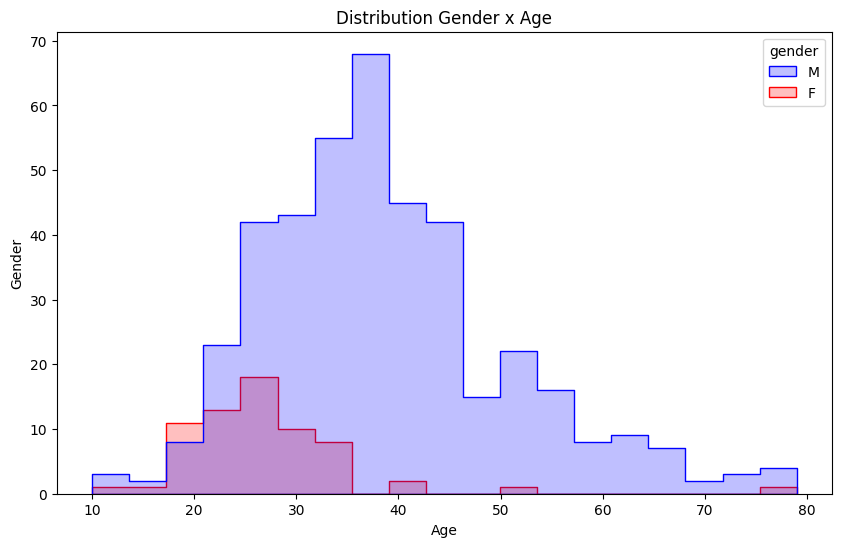

In [11]:
# plot distribution
plt.figure(figsize=(10,6))
sns.histplot(data = df_copy, x='age', hue='gender', element='step', palette={'M': 'blue', 'F': 'red'})
plt.title("Distribution Gender x Age")
plt.xlabel("Age")
plt.ylabel("Gender")
plt.show()

Now i introduced tropes
I want something like : for 18-30 men -> surf dude; for 18-30 women -> girly girl

In [13]:

def top_tropes_by_age_gender(age_group, gender, n=5):
    subset = df_copy[(df_copy['age_bin'] == age_group) & (df_copy['gender'] == gender)]
    return subset['trope_name'].value_counts().head(n)
# Qui la funzione crea una "sottotabella" (subset).
# Usa l'operatore & (AND logico) per tenere solo le righe che soddisfano entrambe le condizioni: devono appartenere a quella fascia d'età E devono essere di quel genere.

# ['0-18', '19-30', '31-40', '41-50', '51-60', '60+']
print(f"Top tropes F (0-18 y):\n{top_tropes_by_age_gender('0-18', 'F')}\n")
print(f"Top tropes M (0-18y):\n{top_tropes_by_age_gender('0-18', 'M')}\n")

print(f"Top tropes F (19-30 y):\n{top_tropes_by_age_gender('19-30', 'F')}\n")
print(f"Top tropes M (19-30 y):\n{top_tropes_by_age_gender('19-30', 'M')}\n")

print(f"Top tropes F (31-40 y):\n{top_tropes_by_age_gender('31-40', 'F')}\n")
print(f"Top tropes M (31-40 y):\n{top_tropes_by_age_gender('31-40', 'M')}\n")

print(f"Top tropes F (41-50 y):\n{top_tropes_by_age_gender('41-50', 'F')}\n")
print(f"Top tropes M (41-50 y):\n{top_tropes_by_age_gender('41-50', 'M')}\n")

print(f"Top tropes F (51-60 y):\n{top_tropes_by_age_gender('51-60', 'F')}\n")
print(f"Top tropes M (51-60 y):\n{top_tropes_by_age_gender('51-60', 'M')}\n")

print(f"Top tropes F (60+ y):\n{top_tropes_by_age_gender('60+', 'F')}\n")
print(f"Top tropes M (60+ y):\n{top_tropes_by_age_gender('60+', 'M')}\n")

Top tropes F (0-18 y):
trope_name
ditz              1
junkie_prophet    1
storyteller       1
valley_girl       1
Name: count, dtype: int64

Top tropes M (0-18y):
trope_name
arrogant_kungfu_guy    1
big_man_on_campus      1
bully                  1
child_prodigy          1
gadgeteer_genius       1
Name: count, dtype: int64

Top tropes F (19-30 y):
trope_name
dumb_blonde         8
final_girl          6
valley_girl         5
brainless_beauty    4
broken_bird         4
Name: count, dtype: int64

Top tropes M (19-30 y):
trope_name
stoner               9
surfer_dude          8
big_man_on_campus    6
jerk_jock            6
slacker              6
Name: count, dtype: int64

Top tropes F (31-40 y):
trope_name
brainless_beauty      3
chanteuse             3
dumb_blonde           2
heartbroken_badass    1
slacker               1
Name: count, dtype: int64

Top tropes M (31-40 y):
trope_name
crazy_jealous_guy              10
psycho_for_hire                 9
corrupt_corporate_executive     8
byroni